# MLP Classification on Iris (Beginner Tutorial)

This notebook is designed as a full end-to-end tutorial, not just a model demo. You will move from data inspection to preprocessing, baseline comparison, neural-network training, and final class-level error analysis.

Learning goals: by the end, you should be able to explain why leakage-safe preprocessing is mandatory, why baseline models are required for honest claims, and how to interpret both a classification report and confusion matrix in context.

Use the same workflow in every section: read the concept first, predict what you expect, run the code, and then explain what the output means in plain language.


## 1. Imports + Reproducibility Seed

This section prepares the computational environment and fixes randomness. In ML, reproducibility is part of scientific method: if results are not repeatable, comparisons are unreliable.

How to read this step: there may be little visible output, so success means imports load without errors and seed-setting executes before data splitting or model fitting. If imports fail, treat that as an environment issue first.

Why this matters later: once seeds are fixed, metric differences between experiments are more likely to reflect real modeling changes rather than random initialization noise.

Go deeper: [TensorFlow/Keras built-in training methods](https://www.tensorflow.org/guide/keras/training_with_built_in_methods).


In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


## 2. Load Dataset

You now load Iris and inspect table structure. This defines the modeling contract: which columns are predictors and which one is the target label.

How to read the output: start with shape and preview together. Shape confirms overall scale; preview confirms semantics. If either is unclear, stop here and clarify before moving forward.

Interpretation habit: if target meaning or class encoding is ambiguous at this stage, every metric later becomes harder to trust. Early schema clarity prevents downstream confusion.

Go deeper: [scikit-learn `load_iris`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html).


In [2]:
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))

feature_cols = iris.feature_names
target_col = 'target'

print('Shape:', df.shape)
df.head()


Shape: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 3. Data Quality Check

Before modeling, you check missing values and duplicate rows. Even with benchmark datasets, explicit quality checks are part of professional practice and reduce hidden failure modes.

How to read the output: read missing counts by column, then duplicate count, then post-cleaning shape. Small or zero changes are common here, but if changes are large, document them because they can shift class distribution and performance.

Interpretation rule: cleaning is not just housekeeping; it changes the training distribution. Treat this section as part of model design, not a separate data step.

Go deeper: [Common pitfalls in scikit-learn](https://scikit-learn.org/stable/common_pitfalls.html).


In [3]:
print('Missing values by column:\n', df.isna().sum())
print('Duplicate rows:', df.duplicated().sum())

df = df.drop_duplicates().copy()
print('Shape after duplicate removal:', df.shape)


Missing values by column:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64
Duplicate rows: 1
Shape after duplicate removal: (149, 6)


## 4. EDA (PCA + t-SNE)

This section builds intuition before fitting models. You combine pairplots with PCA and t-SNE to understand separability, overlap, and geometric structure.

How to read the PCA printout: the notebook now prints named components (`PC1`, `PC2`) plus cumulative variance. If `PC1=0.73` and `PC2=0.23`, then together they retain about `0.96` (96%) of total variance in a 2D linear projection.

How to read PCA composition output: the loadings table shows how strongly each original feature contributes to each component. Larger absolute loading means stronger contribution; sign (`+/-`) indicates direction along that component axis, not “good/bad” importance.

How to read this in context: high cumulative PCA variance means the 2D projection keeps much of the feature variation, but it does **not** guarantee perfect class separation. t-SNE adds a local-neighborhood view, which is useful for visual hypotheses, but global distances in t-SNE should not be interpreted as exact geometry.

Use EDA outputs to form hypotheses about likely confusion pairs, then verify those hypotheses in final evaluation.

Go deeper on dimensionality reduction and interpretation: [scikit-learn PCA](https://scikit-learn.org/stable/modules/decomposition.html#pca), [scikit-learn t-SNE](https://scikit-learn.org/stable/modules/manifold.html#t-sne), [How to Use t-SNE Effectively (Distill)](https://distill.pub/2016/misread-tsne/), and [van der Maaten & Hinton (2008)](https://www.jmlr.org/papers/v9/vandermaaten08a.html).


PCA explained variance ratio -> PC1: 0.7299, PC2: 0.2286
PCA cumulative explained variance (PC1+PC2): 0.9585

PCA component loadings (feature contributions):


,PC1_loading,PC2_loading
sepal length (cm),0.5221,0.3733
sepal width (cm),-0.2677,0.9249
petal length (cm),0.5803,0.0243
petal width (cm),0.5648,0.0683


Top features shaping PC1: petal length (cm), petal width (cm), sepal length (cm)
Top features shaping PC2: sepal width (cm), sepal length (cm), petal width (cm)


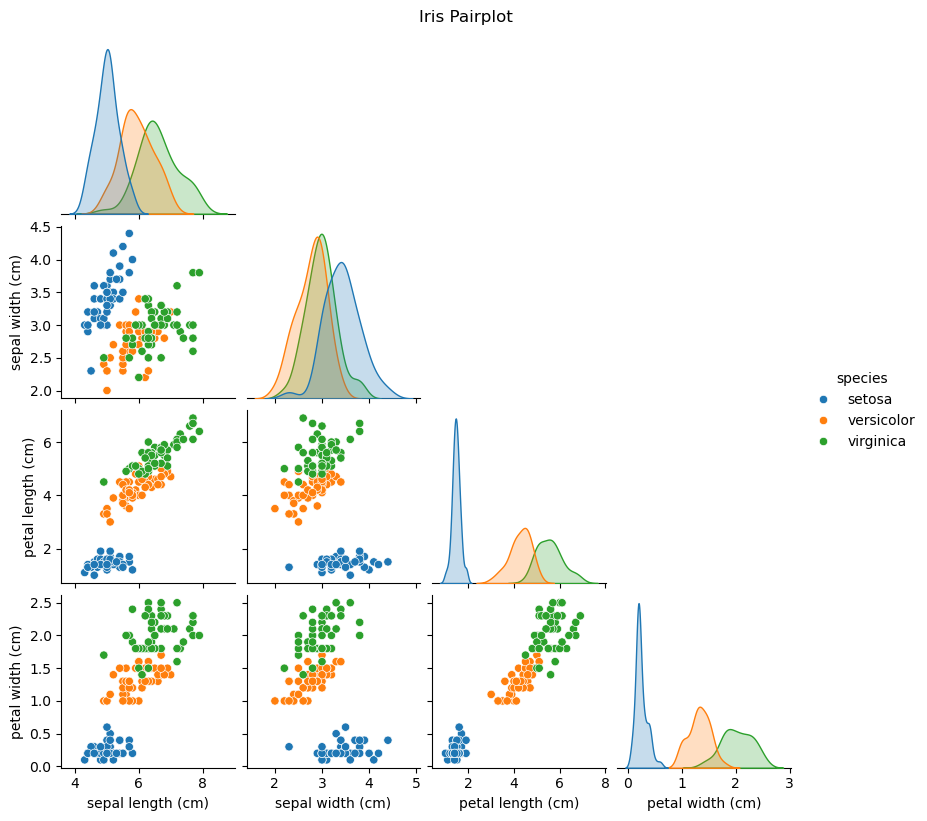

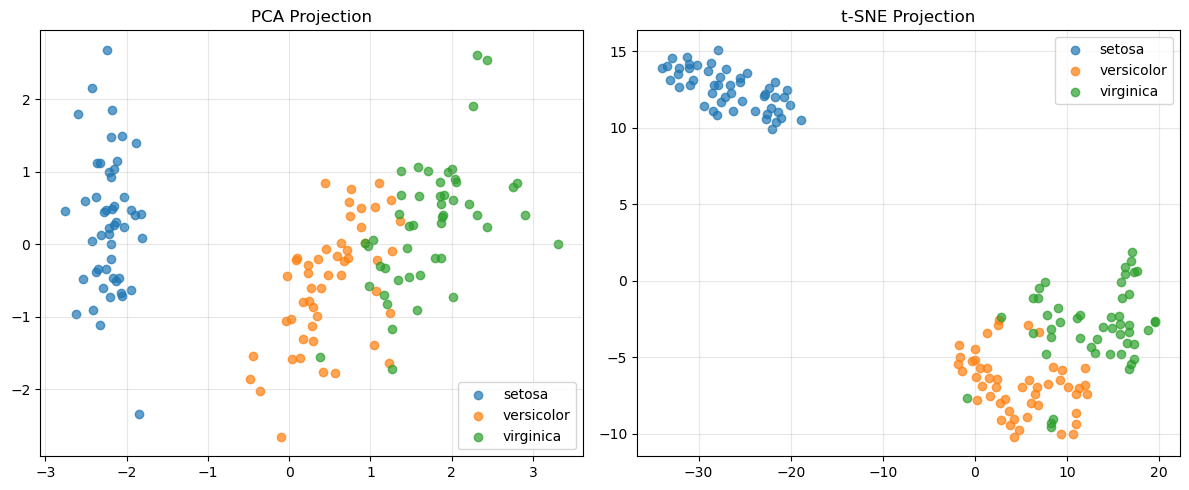

In [4]:
X_eda = df[feature_cols].to_numpy()
y_eda = df[target_col].to_numpy()

X_eda_scaled = StandardScaler().fit_transform(X_eda)

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_eda_scaled)
explained = pca.explained_variance_ratio_
print(f"PCA explained variance ratio -> PC1: {explained[0]:.4f}, PC2: {explained[1]:.4f}")
print(f"PCA cumulative explained variance (PC1+PC2): {explained.sum():.4f}")

# PCA composition: how each original feature contributes to each principal component.
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=['PC1_loading', 'PC2_loading'],
)
print()
print("PCA component loadings (feature contributions):")
display(loadings.style.format('{:.4f}'))

for pc in ['PC1_loading', 'PC2_loading']:
    top_features = loadings[pc].abs().sort_values(ascending=False).head(3).index.tolist()
    print(f"Top features shaping {pc.replace('_loading', '')}: {', '.join(top_features)}")

sns.pairplot(df, vars=feature_cols, hue='species', corner=True, height=2)
plt.suptitle('Iris Pairplot', y=1.02)
plt.show()

# t-SNE is kept tiny here because Iris is very small.
X_tsne = TSNE(n_components=2, perplexity=20, max_iter=1000, random_state=SEED).fit_transform(X_eda_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for class_id, class_name in enumerate(iris.target_names):
    mask = y_eda == class_id
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.7, label=class_name)
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], alpha=0.7, label=class_name)

axes[0].set_title('PCA Projection')
axes[1].set_title('t-SNE Projection')
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()


## 5. Preprocessing

This section creates explicit `X` (features) and `y` (labels). Keeping this explicit is useful for beginners because it makes leakage and alignment errors easier to detect.

How to read the output: confirm `X` has shape `(n_samples, n_features)` and `y` has shape `(n_samples,)`. The sample count must match exactly.

Interpretation rule: if sample counts differ, you do not have a modeling problem yet; you have a data-pipeline integrity problem. Fix it before splitting.


In [5]:
X = df[feature_cols].to_numpy()
y = df[target_col].to_numpy()

print('X shape:', X.shape)
print('y shape:', y.shape)


X shape: (149, 4)
y shape: (149,)


## 6. Train/Val/Test Split

This section performs train/validation/test partitioning and scaling with train-only fitting. This is the core anti-leakage step in the notebook.

How to read the output: verify split sizes, verify that feature dimensions are consistent across train/val/test, and verify that sample totals reconcile with cleaned data size.

Contextual interpretation: if scaling was fit before splitting, evaluation becomes optimistic. If shapes mismatch, any later metric is invalid regardless of model type.

Go deeper on leakage-safe splitting and scaling: [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html), [data leakage guidance](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage), and [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html).


In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=SEED,
    stratify=y,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=SEED,
    stratify=y_temp,
)

scaler = StandardScaler()
# Leakage-safe scaling: fit ONLY on training data.
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

print('Train:', X_train_s.shape, 'Val:', X_val_s.shape, 'Test:', X_test_s.shape)


Train: (89, 4) Val: (30, 4) Test: (30, 4)


## 7. Baseline Model

You train logistic regression as the baseline reference. Baselines define the minimum acceptable performance and prevent over-claiming neural-network gains.

How to read the `classification_report` output: `precision` measures correctness of predicted class assignments, `recall` measures recovery of true class instances, `f1-score` balances both, and `support` tells you class sample count.

Contextual interpretation: inspect per-class metrics first, then macro/weighted averages. The MLP must beat this baseline in a meaningful way to justify extra complexity.

Go deeper: [LogisticRegression API](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html).


In [7]:
baseline = LogisticRegression(max_iter=300, random_state=SEED)
baseline.fit(X_train_s, y_train)
baseline_pred = baseline.predict(X_test_s)

print('Baseline (Logistic Regression) report:\n')
print(classification_report(y_test, baseline_pred, target_names=iris.target_names))


Baseline (Logistic Regression) report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



## 8. Neural Network Model

Now you train a compact MLP with early stopping. The objective is controlled generalization, not maximum parameter count.

How to read this step: printed output may be limited, so interpret this stage primarily through the upcoming training curves and final report. Watch for stable validation behavior, not just improving train metrics.

Contextual interpretation: if validation stagnates while train improves, model capacity or training duration may be too aggressive.

Go deeper on model construction and stopping criteria: [Keras Sequential guide](https://keras.io/guides/sequential_model/) and [EarlyStopping](https://keras.io/api/callbacks/early_stopping/).


In [8]:
model = keras.Sequential([
    keras.layers.Input(shape=(X_train_s.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(len(np.unique(y)), activation='softmax'),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
)

history = model.fit(
    X_train_s,
    y_train,
    validation_data=(X_val_s, y_val),
    epochs=256,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1,
)


Epoch 1/256
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.4382 - loss: 1.1707 - val_accuracy: 0.4333 - val_loss: 1.1183
Epoch 2/256
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4944 - loss: 1.0512 - val_accuracy: 0.5667 - val_loss: 1.0065
Epoch 3/256
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5955 - loss: 0.9477 - val_accuracy: 0.7000 - val_loss: 0.9106
Epoch 4/256
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6966 - loss: 0.8355 - val_accuracy: 0.8000 - val_loss: 0.8301
Epoch 5/256
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7303 - loss: 0.7888 - val_accuracy: 0.8000 - val_loss: 0.7631
Epoch 6/256
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7753 - loss: 0.7076 - val_accuracy: 0.8000 - val_loss: 0.7071
Epoch 7/256
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7978 - loss: 0.6514 - val_accuracy: 0.8000 - val_loss: 0.6606
Epoch 8/256
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8202 - loss: 0.6240 - val_accuracy: 0.8000 - val_loss: 0

## 9. Training Curves

This section converts training history into diagnostics. Curves are often the fastest way to distinguish underfitting, healthy convergence, and overfitting.

How to read the plots: compare train and validation trajectories over time. Parallel improvements suggest healthy learning. Large divergence suggests overfitting pressure.

Use these plots as decision tools: they should guide your next hyperparameter or architecture change.


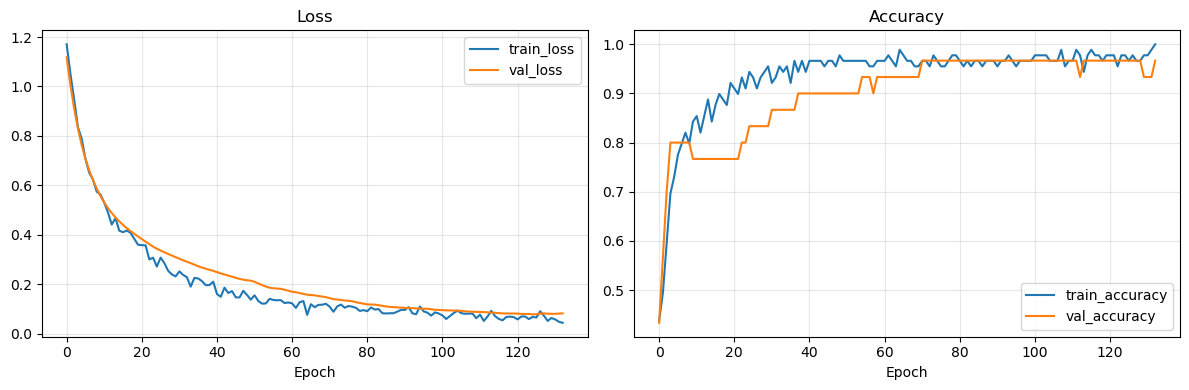

In [9]:
history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df['loss'], label='train_loss')
axes[0].plot(history_df['val_loss'], label='val_loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(history_df['accuracy'], label='train_accuracy')
axes[1].plot(history_df['val_accuracy'], label='val_accuracy')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


## 10. Final Evaluation

You now evaluate on the held-out test set with a classification report and confusion matrix.

How to read the report: interpret per-class precision/recall/F1 first, then compare against baseline values from section 7. This tells you whether gains are broad or concentrated in specific classes.

How to read the confusion matrix: rows are true classes and columns are predicted classes. Off-diagonal cells are specific error pathways. Compare these pathways to overlap patterns you observed during EDA.

Go deeper: [classification_report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) and [ConfusionMatrixDisplay](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html).


MLP report:

              precision    recall  f1-score   support

      setosa       1.00      0.90      0.95        10
  versicolor       0.77      1.00      0.87        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.90        30
   macro avg       0.92      0.90      0.90        30
weighted avg       0.92      0.90      0.90        30



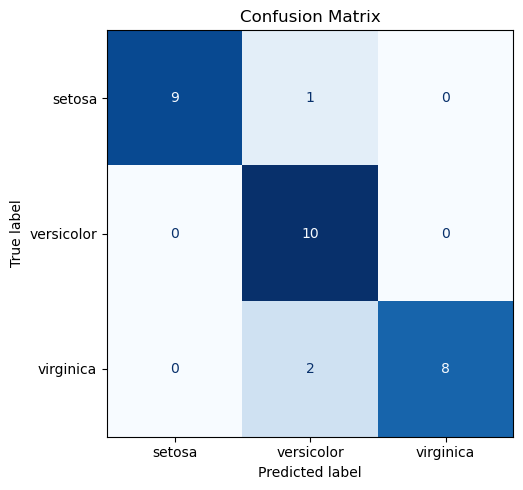

In [10]:
test_pred = model.predict(X_test_s, verbose=0).argmax(axis=1)

print('MLP report:\n')
print(classification_report(y_test, test_pred, target_names=iris.target_names))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred,
    display_labels=iris.target_names,
    cmap='Blues',
    colorbar=False,
    ax=ax,
)
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()


## 11. Mini Exercises

Use this section as a structured experiment log. For each change, write your prediction first, run the notebook section, then explain the observed output using metrics and plots rather than intuition alone.


1. Change dropout from `0.2` to `0.0`, retrain, and explain how the train-vs-validation gap changes.
2. Try t-SNE perplexity values `5` and `40`, then explain what changes visually and what conclusions remain stable.
3. Remove `StandardScaler` and describe changes in optimization behavior and final performance.
4. Add one hidden layer and decide whether added complexity is justified by measurable gains.

For broader study, keep the [scikit-learn user guide](https://scikit-learn.org/stable/user_guide.html) and [TensorFlow/Keras guides](https://www.tensorflow.org/guide/keras) open while experimenting.
